⚡ Running EV Powertrain Simulation...
   EV POWERTRAIN SIMULATION — RESULTS SUMMARY
  Drive cycle distance        : 7.90 km
  Total energy consumed       : 879.2 Wh
  Energy recovered (regen)    : 123.3 Wh
  Regen recovery rate         : 14.0%
  Net energy used             : 755.8 Wh
  Consumption                 : 95.6 Wh/km
  SoC change                  : 3.20%
  Average motor efficiency    : 84.3%
  Fault events                : 0


/tmp/ipykernel_3963/2811581304.py:413: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  dist_km    = np.trapz(res['v_actual'], res['t']) / 1000


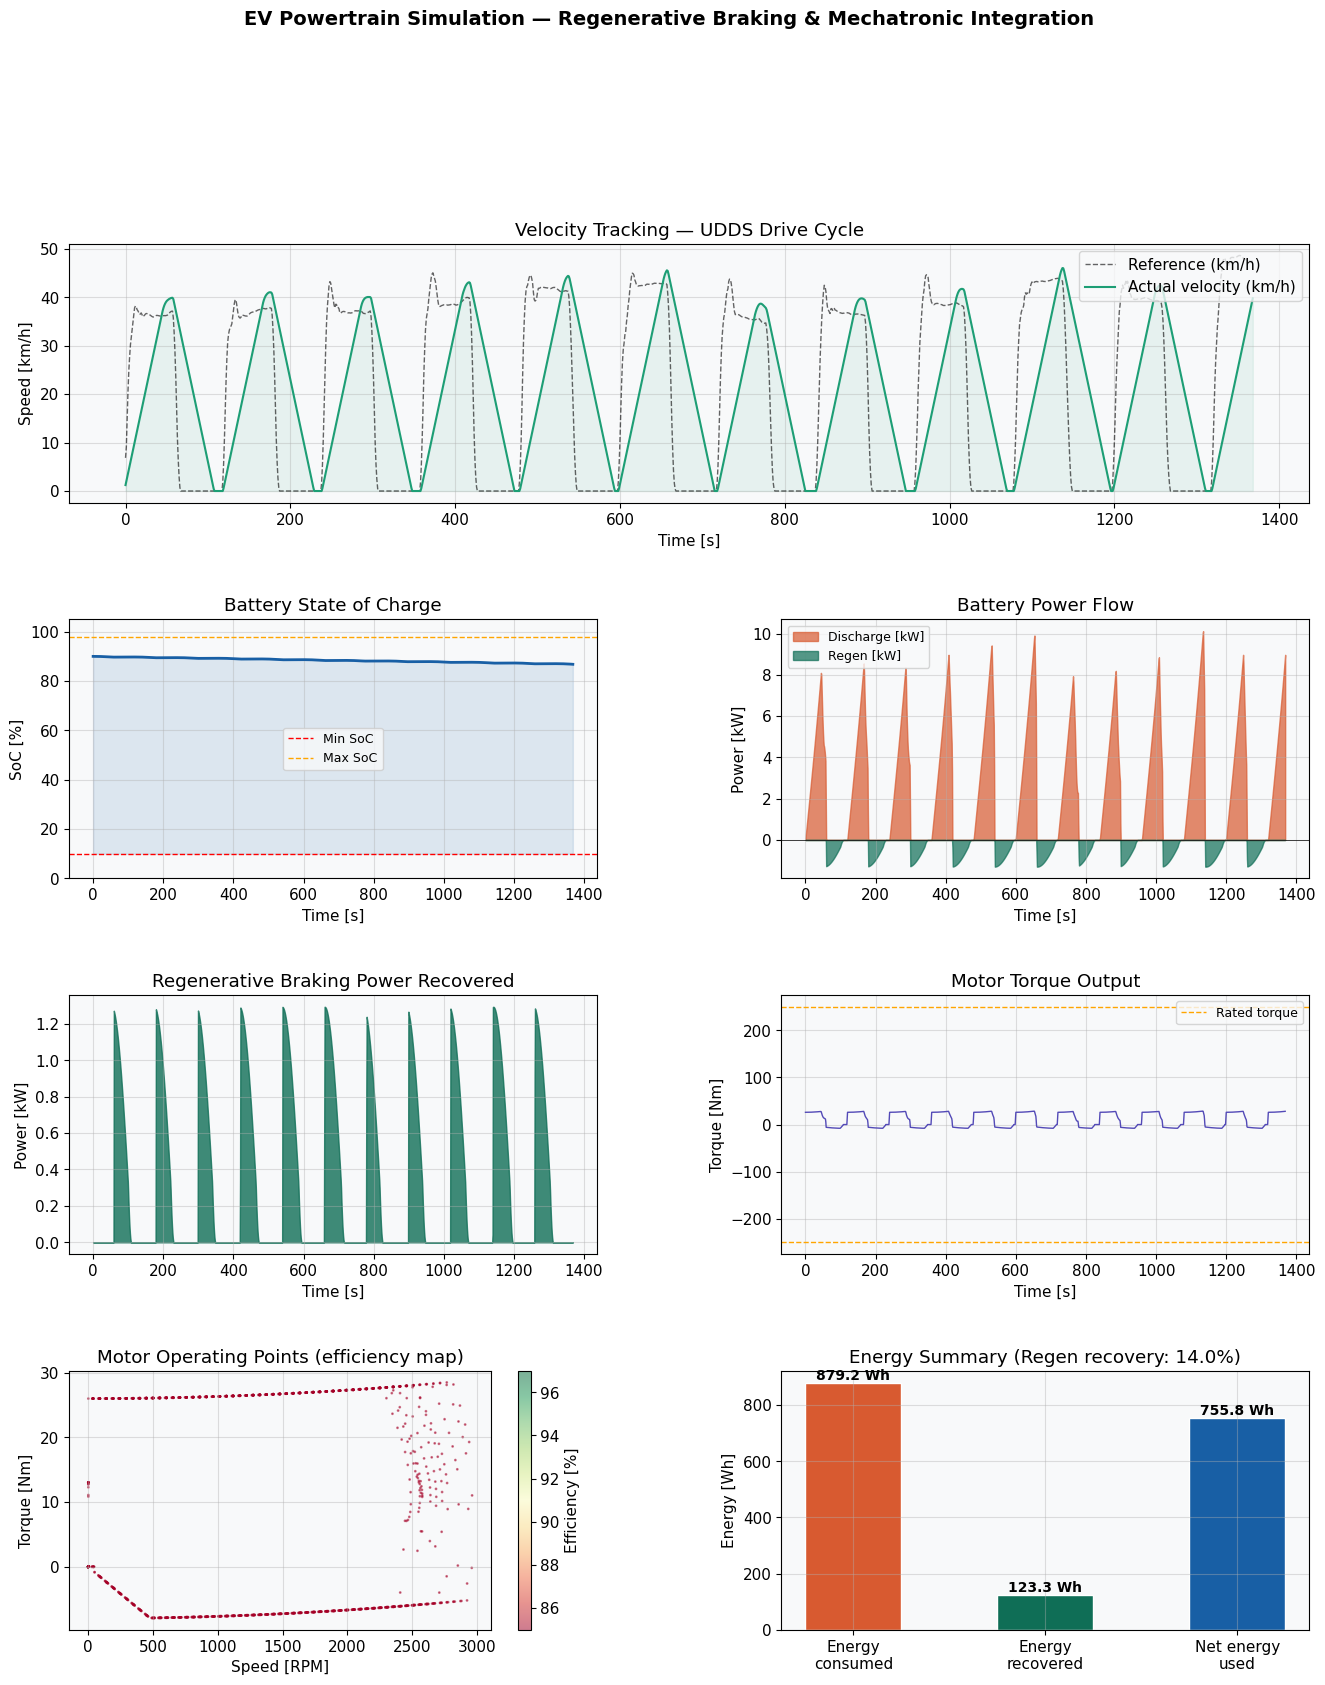


✅ Plot saved as 'ev_simulation_results.png'


In [ ]:
# ============================================================
#  EV Powertrain with Regenerative Braking & Mechatronic
# ============================================================


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
                     'axes.grid': True, 'grid.alpha': 0.4, 'font.size': 11})

# ─────────────────────────────────────────────
# 1. SYSTEM PARAMETERS
# ─────────────────────────────────────────────
class EVParameters:
    # --- Battery (Equivalent Circuit Model) ---
    V_nom       = 400.0     # Nominal pack voltage [V]
    Q_cap       = 60.0      # Battery capacity [Ah]
    R_int       = 0.05      # Internal resistance [Ohm]
    SoC_init    = 0.90      # Initial State of Charge
    SoC_min     = 0.10      # Minimum SoC (protection)
    SoC_max     = 0.98      # Maximum SoC (regen limit)
    eta_batt    = 0.97      # Battery round-trip efficiency

    # --- Motor (PMSM approximation) ---
    T_rated     = 250.0     # Rated torque [Nm]
    T_max       = 400.0     # Peak torque [Nm]
    omega_base  = 314.0     # Base angular velocity [rad/s] (~3000 RPM)
    omega_max   = 1047.0    # Max angular velocity [rad/s] (~10000 RPM)
    eta_motor   = 0.94      # Motor efficiency (motoring)
    eta_regen   = 0.88      # Generator efficiency (regenerating)

    # --- Inverter / Power Electronics ---
    eta_inv     = 0.97      # Inverter efficiency
    f_pwm       = 10000     # PWM switching frequency [Hz]

    # --- DC-DC Converter ---
    eta_dcdc    = 0.95      # DC-DC converter efficiency

    # --- Vehicle Dynamics ---
    m_veh       = 1800.0    # Vehicle mass [kg] (incl. passengers)
    C_d         = 0.28      # Aerodynamic drag coefficient
    A_front     = 2.4       # Frontal area [m²]
    C_rr        = 0.012     # Rolling resistance coefficient
    r_wheel     = 0.33      # Wheel radius [m]
    rho_air     = 1.225     # Air density [kg/m³]
    g           = 9.81      # Gravity [m/s²]
    gear_ratio  = 8.0       # Single-speed gearbox ratio
    eta_trans   = 0.97      # Transmission efficiency

    # --- PID Controller ---
    Kp          = 300.0     # Proportional gain
    Ki          = 20.0      # Integral gain
    Kd          = 5.0       # Derivative gain

    # --- Thermal (simplified) ---
    T_motor_max = 120.0     # Max motor temperature [°C]
    T_batt_max  = 45.0      # Max battery temperature [°C]
    T_ambient   = 25.0      # Ambient temperature [°C]

prm = EVParameters()

# ─────────────────────────────────────────────
# 2. DRIVE CYCLE (UDDS — Urban Dynamometer)
# ─────────────────────────────────────────────
def generate_udds_cycle():
    """
    Simplified UDDS-like velocity profile.
    Returns time [s] and velocity [m/s] arrays.
    """
    np.random.seed(42)
    t_total = 1369          # UDDS duration [s]
    t = np.arange(0, t_total, 1.0)

    # Build piecewise velocity with acceleration, cruise, braking
    segments = []
    v = 0.0
    profile = [v]
    for i in range(1, len(t)):
        phase = int(t[i]) % 120
        if phase < 20:
            target = np.random.uniform(8, 15)
            dv = min(2.5, max(-3.0, (target - v) * 0.3 + np.random.randn() * 0.1))
        elif phase < 60:
            dv = np.random.randn() * 0.05
        elif phase < 90:
            dv = -np.random.uniform(1.0, 2.5)
        else:
            dv = 0.0
            v = 0.0
        v = max(0.0, min(v + dv, 33.3))  # clip 0–120 km/h
        profile.append(v)

    # Smooth it
    from scipy.ndimage import uniform_filter1d
    velocity = uniform_filter1d(np.array(profile), size=5)
    return t, velocity

# ─────────────────────────────────────────────
# 3. VEHICLE DYNAMICS MODEL
# ─────────────────────────────────────────────
def calc_road_load(v_mps):
    """Returns road load force [N] at speed v [m/s]."""
    F_aero = 0.5 * prm.rho_air * prm.C_d * prm.A_front * v_mps**2
    F_roll = prm.C_rr * prm.m_veh * prm.g
    return F_aero + F_roll

def calc_motor_torque_demand(F_demand, v_mps):
    """Convert wheel force demand to motor torque demand."""
    T_wheel = F_demand * prm.r_wheel
    T_motor = T_wheel / (prm.gear_ratio * prm.eta_trans)
    omega_motor = (v_mps / prm.r_wheel) * prm.gear_ratio
    return T_motor, omega_motor

# ─────────────────────────────────────────────
# 4. MOTOR EFFICIENCY MAP (simplified)
# ─────────────────────────────────────────────
def motor_efficiency(T_demand, omega):
    """Returns motor efficiency based on operating point."""
    T_abs = abs(T_demand)
    if omega < 1e-3 or T_abs < 1e-3:
        return 0.0
    # Torque limiting in field-weakening region
    T_max_at_omega = min(prm.T_max, prm.T_max * prm.omega_base / max(omega, prm.omega_base))
    T_actual = np.clip(T_abs, 0, T_max_at_omega)
    load_ratio = T_actual / prm.T_rated
    # Gaussian-like efficiency peak at 70% load
    eta = prm.eta_motor * np.exp(-0.3 * (load_ratio - 0.7)**2)
    return np.clip(eta, 0.70, prm.eta_motor)

# ─────────────────────────────────────────────
# 5. BATTERY MODEL (Equivalent Circuit)
# ─────────────────────────────────────────────
class Battery:
    def __init__(self):
        self.SoC = prm.SoC_init
        self.V_oc = self._ocv(self.SoC)
        self.T_batt = prm.T_ambient
        self.energy_in  = 0.0   # [Wh] energy recharged
        self.energy_out = 0.0   # [Wh] energy discharged

    def _ocv(self, SoC):
        """Open-circuit voltage vs SoC (linear approximation)."""
        return prm.V_nom * (0.85 + 0.15 * SoC)

    def update(self, P_batt_demand, dt):
        """
        P_batt_demand > 0 → discharge (motoring)
        P_batt_demand < 0 → charge (regenerating)
        Returns: V_terminal, I_batt, fault_flag
        """
        self.V_oc = self._ocv(self.SoC)
        # Solve quadratic: V_oc*I - R_int*I^2 = P (discharge)
        # For charge: P negative
        discriminant = self.V_oc**2 - 4 * prm.R_int * P_batt_demand
        if discriminant < 0:
            discriminant = 0
        I_batt = (self.V_oc - np.sqrt(discriminant)) / (2 * prm.R_int)
        V_term = self.V_oc - I_batt * prm.R_int

        # SoC update via Coulomb counting
        delta_SoC = -(I_batt * dt) / (prm.Q_cap * 3600)
        self.SoC = np.clip(self.SoC + delta_SoC, prm.SoC_min, prm.SoC_max)

        # Energy tracking
        P_actual = V_term * I_batt
        if P_actual > 0:
            self.energy_out += P_actual * dt / 3600
        else:
            self.energy_in  += abs(P_actual) * dt / 3600

        # Fault flags
        fault = False
        if self.SoC <= prm.SoC_min + 0.01:
            fault = True   # Low SoC protection
        return V_term, I_batt, fault

# ─────────────────────────────────────────────
# 6. PID TORQUE CONTROLLER
# ─────────────────────────────────────────────
class PIDController:
    def __init__(self, Kp, Ki, Kd, dt, limit=prm.T_max):
        self.Kp, self.Ki, self.Kd = Kp, Ki, Kd
        self.dt = dt
        self.limit = limit
        self._integral = 0.0
        self._prev_err = 0.0

    def update(self, setpoint, measured):
        err = setpoint - measured
        self._integral += err * self.dt
        self._integral = np.clip(self._integral, -self.limit / self.Ki,
                                  self.limit / self.Ki)
        derivative = (err - self._prev_err) / self.dt
        output = self.Kp * err + self.Ki * self._integral + self.Kd * derivative
        self._prev_err = err
        return np.clip(output, -self.limit, self.limit)

# ─────────────────────────────────────────────
# 7. REGENERATIVE BRAKING CONTROLLER
# ─────────────────────────────────────────────
def regen_controller(T_brake_demand, omega, SoC, V_terminal):
    """
    Decides how much braking is regenerative vs mechanical.
    Returns: T_regen [Nm], T_mech_brake [Nm], P_recovered [W]
    """
    if T_brake_demand >= 0 or omega < 5.0 or SoC >= prm.SoC_max:
        return 0.0, abs(T_brake_demand), 0.0

    T_demand_abs = abs(T_brake_demand)
    # Max regen torque limited by motor capability
    T_regen_max = min(T_demand_abs, prm.T_max * 0.6)
    # Blend: at low speed, reduce regen (stability)
    blend = np.clip(omega / 50.0, 0.0, 1.0)
    T_regen = T_regen_max * blend
    T_mech   = T_demand_abs - T_regen

    # Power recovered after efficiencies
    P_mech_at_motor = T_regen * omega
    P_recovered = P_mech_at_motor * prm.eta_regen * prm.eta_inv * prm.eta_dcdc
    return T_regen, T_mech, P_recovered

# ─────────────────────────────────────────────
# 8. MAIN SIMULATION LOOP
# ─────────────────────────────────────────────
def run_simulation():
    t_arr, v_ref = generate_udds_cycle()
    dt = t_arr[1] - t_arr[0]
    N  = len(t_arr)

    batt    = Battery()
    pid     = PIDController(prm.Kp, prm.Ki, prm.Kd, dt)

    # State arrays
    v_actual    = np.zeros(N)
    SoC_arr     = np.zeros(N)
    P_motor_arr = np.zeros(N)
    P_regen_arr = np.zeros(N)
    T_motor_arr = np.zeros(N)
    omega_arr   = np.zeros(N)
    eta_arr     = np.zeros(N)
    fault_arr   = np.zeros(N, dtype=bool)
    I_batt_arr  = np.zeros(N)

    v = 0.0
    fault_active = False

    for i in range(N):
        SoC_arr[i] = batt.SoC

        if fault_active:
            fault_arr[i] = True
            v = max(0, v - 2.0 * dt)  # coast to stop
            v_actual[i] = v
            continue

        v_set = v_ref[i]

        # PID → force demand
        a_demand = pid.update(v_set, v) / prm.m_veh
        F_demand = prm.m_veh * a_demand
        F_road   = calc_road_load(v)
        F_total  = F_demand + np.sign(v + 1e-3) * F_road

        # Motor torque & speed
        T_demand, omega = calc_motor_torque_demand(F_total, max(v, 0.01))
        omega = np.clip(omega, 0, prm.omega_max)

        # Regenerative braking decision
        T_regen, T_mech, P_recovered = regen_controller(T_demand, omega, batt.SoC,
                                                         batt.V_oc)

        if T_demand < 0:
            # Braking mode
            P_batt_demand = -P_recovered   # negative = charging
            eta_op = prm.eta_regen
            P_regen_arr[i] = P_recovered
            T_motor_arr[i] = -T_regen
        else:
            # Motoring mode
            eta_op = motor_efficiency(T_demand, omega)
            P_mech = T_demand * omega
            P_elec = P_mech / (eta_op * prm.eta_inv + 1e-9)
            P_batt_demand = P_elec
            T_motor_arr[i] = T_demand
            eta_arr[i] = eta_op

        P_motor_arr[i] = P_batt_demand
        omega_arr[i]   = omega

        # Battery update
        V_term, I_batt, fault = batt.update(P_batt_demand, dt)
        I_batt_arr[i] = I_batt
        if fault:
            fault_active = True

        # Vehicle dynamics integration (Euler)
        F_wheel_actual = (T_demand * prm.gear_ratio * prm.eta_trans) / prm.r_wheel
        a_actual = (F_wheel_actual - np.sign(v) * F_road) / prm.m_veh
        v = max(0.0, v + a_actual * dt)
        v_actual[i] = v

    return {
        't': t_arr, 'v_ref': v_ref, 'v_actual': v_actual,
        'SoC': SoC_arr, 'P_motor': P_motor_arr, 'P_regen': P_regen_arr,
        'T_motor': T_motor_arr, 'omega': omega_arr, 'eta': eta_arr,
        'fault': fault_arr, 'I_batt': I_batt_arr,
        'energy_out': batt.energy_out, 'energy_in': batt.energy_in
    }

# ─────────────────────────────────────────────
# 9. POST-PROCESSING & VISUALISATION
# ─────────────────────────────────────────────
def plot_results(res):
    fig = plt.figure(figsize=(16, 18))
    gs  = gridspec.GridSpec(4, 2, hspace=0.45, wspace=0.35)
    t   = res['t']

    # ── Plot 1: Velocity Tracking
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(t, res['v_ref']*3.6,   'k--', lw=1, alpha=0.6, label='Reference (km/h)')
    ax1.plot(t, res['v_actual']*3.6, '#1D9E75', lw=1.5, label='Actual velocity (km/h)')
    ax1.fill_between(t, 0, res['v_actual']*3.6, alpha=0.08, color='#1D9E75')
    ax1.set_title('Velocity Tracking — UDDS Drive Cycle')
    ax1.set_ylabel('Speed [km/h]')
    ax1.set_xlabel('Time [s]')
    ax1.legend(loc='upper right')

    # ── Plot 2: State of Charge
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(t, res['SoC']*100, '#185FA5', lw=2)
    ax2.axhline(prm.SoC_min*100, color='red', ls='--', lw=1, label='Min SoC')
    ax2.axhline(prm.SoC_max*100, color='orange', ls='--', lw=1, label='Max SoC')
    ax2.fill_between(t, prm.SoC_min*100, res['SoC']*100, alpha=0.12, color='#185FA5')
    ax2.set_title('Battery State of Charge')
    ax2.set_ylabel('SoC [%]')
    ax2.set_xlabel('Time [s]')
    ax2.set_ylim([0, 105])
    ax2.legend(fontsize=9)

    # ── Plot 3: Power Flow
    ax3 = fig.add_subplot(gs[1, 1])
    P_kW = res['P_motor'] / 1000
    ax3.fill_between(t, 0, np.where(P_kW > 0, P_kW, 0),
                     color='#D85A30', alpha=0.7, label='Discharge [kW]')
    ax3.fill_between(t, 0, np.where(P_kW < 0, P_kW, 0),
                     color='#0F6E56', alpha=0.7, label='Regen [kW]')
    ax3.set_title('Battery Power Flow')
    ax3.set_ylabel('Power [kW]')
    ax3.set_xlabel('Time [s]')
    ax3.axhline(0, color='black', lw=0.5)
    ax3.legend(fontsize=9)

    # ── Plot 4: Regenerated Power
    ax4 = fig.add_subplot(gs[2, 0])
    ax4.fill_between(t, 0, res['P_regen']/1000, color='#0F6E56', alpha=0.8)
    ax4.set_title('Regenerative Braking Power Recovered')
    ax4.set_ylabel('Power [kW]')
    ax4.set_xlabel('Time [s]')

    # ── Plot 5: Motor Torque
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.plot(t, res['T_motor'], '#534AB7', lw=1)
    ax5.axhline(prm.T_rated, color='orange', ls='--', lw=1, label='Rated torque')
    ax5.axhline(-prm.T_rated, color='orange', ls='--', lw=1)
    ax5.set_title('Motor Torque Output')
    ax5.set_ylabel('Torque [Nm]')
    ax5.set_xlabel('Time [s]')
    ax5.legend(fontsize=9)

    # ── Plot 6: Motor Operating Map
    ax6 = fig.add_subplot(gs[3, 0])
    omega_rpm = res['omega'] * 60 / (2 * np.pi)
    sc = ax6.scatter(omega_rpm, res['T_motor'], c=res['eta']*100,
                     cmap='RdYlGn', s=1, alpha=0.5, vmin=85, vmax=97)
    plt.colorbar(sc, ax=ax6, label='Efficiency [%]')
    ax6.set_title('Motor Operating Points (efficiency map)')
    ax6.set_xlabel('Speed [RPM]')
    ax6.set_ylabel('Torque [Nm]')

    # ── Plot 7: Energy Summary Bar Chart
    ax7 = fig.add_subplot(gs[3, 1])
    categories = ['Energy\nconsumed', 'Energy\nrecovered', 'Net energy\nused']
    net = res['energy_out'] - res['energy_in']
    values = [res['energy_out'], res['energy_in'], net]
    colors  = ['#D85A30', '#0F6E56', '#185FA5']
    bars = ax7.bar(categories, values, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, values):
        ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f} Wh', ha='center', va='bottom', fontsize=10, fontweight='bold')
    regen_pct = 100 * res['energy_in'] / max(res['energy_out'], 1)
    ax7.set_title(f'Energy Summary (Regen recovery: {regen_pct:.1f}%)')
    ax7.set_ylabel('Energy [Wh]')

    plt.suptitle('EV Powertrain Simulation — Regenerative Braking & Mechatronic Integration',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.savefig('ev_simulation_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Plot saved as 'ev_simulation_results.png'")

# ─────────────────────────────────────────────
# 10. METRICS REPORT
# ─────────────────────────────────────────────
def print_metrics(res):
    regen_pct  = 100 * res['energy_in'] / max(res['energy_out'], 1)
    SoC_drop   = (res['SoC'][0] - res['SoC'][-1]) * 100
    avg_eta    = np.mean(res['eta'][res['eta'] > 0]) * 100
    dist_km    = np.trapz(res['v_actual'], res['t']) / 1000
    consumption_Wh_km = (res['energy_out'] - res['energy_in']) / max(dist_km, 0.01)

    print("=" * 55)
    print("   EV POWERTRAIN SIMULATION — RESULTS SUMMARY")
    print("=" * 55)
    print(f"  Drive cycle distance        : {dist_km:.2f} km")
    print(f"  Total energy consumed       : {res['energy_out']:.1f} Wh")
    print(f"  Energy recovered (regen)    : {res['energy_in']:.1f} Wh")
    print(f"  Regen recovery rate         : {regen_pct:.1f}%")
    print(f"  Net energy used             : {res['energy_out']-res['energy_in']:.1f} Wh")
    print(f"  Consumption                 : {consumption_Wh_km:.1f} Wh/km")
    print(f"  SoC change                  : {SoC_drop:.2f}%")
    print(f"  Average motor efficiency    : {avg_eta:.1f}%")
    print(f"  Fault events                : {res['fault'].sum()}")
    print("=" * 55)

# ─────────────────────────────────────────────
# 11. RUN
# ─────────────────────────────────────────────
if __name__ == '__main__':
    print("⚡ Running EV Powertrain Simulation...")
    results = run_simulation()
    print_metrics(results)
    plot_results(results)